# Elements in the Biosphere

Now we will plot data sets of elements in the Earth's crust, see and living things. 

Some of my data sets have symbols but not atomic numbers and vice versa. I also need average atomic weights so that I can convert between mole fractions and mass fractions. I found a table of alleged periodic [table data](https://raw.githubusercontent.com/frictionlessdata/example-data-packages/62d47b454d95a95b6029214b9533de79401e953a/periodic-table/data.csv) at a [random website](https://frictionlessdata.io/blog/2018/02/16/using-data-packages-in-go/#the-periodic-table-data-package) selling data analysis software. I edited the file to include comments about the source and a set of column names. I should [check the masses](https://physics.nist.gov/cgi-bin/Compositions/stand_alone.pl) by comparing the values to the National Institute of Standards and technology (NIST) data, but I'm lazy enough to trust iy.

## Collect data into DataFrames

I will load in the csv data from the periodic table data set. I named the edited file as [atomicinfo.csv](data/atomicinfo.csv)

In [13]:
import pandas as pd

df = pd.read_csv("data/atomicinfo.csv",
                 comment="#", 
                 skipinitialspace=True)

df = df.drop(columns=["type"]) # remove unneeded 'type' column
df.head(3)

,number,symbol,name,mass
0,1,H,Hydrogen,1.007940
1,2,He,Helium,4.002602
2,3,Li,Lithium,6.941000


I found a set of data from a textbook. I had to type in the numbers as it was available on paper only. The data is in the file [SphericalCow.csv](data/SphericalCow.csv)

> Harte, J., "Consider a Spherical Cow: A Course in Environmental Problem Solving." *University Science Books, Berkeley*, **1988**, p.243 isbn:978-0935702583



In [14]:
import pandas as pd

dfcow = pd.read_csv("data/SphericalCow.csv",
                 comment="#", 
                 skipinitialspace=True)
dfcow.head(3)

,symbol,crust,seawater,biomass
0,O,456000.0,857000.00,630000.0
1,Si,273000.0,3.00,15000.0
2,Al,83600.0,0.01,500.0


Now I will combine the two data sets to create a new data set that is the intersection of the two according to atomic symbol, which is common to both sets.

In [15]:
# Merge the two dataframes on the "symbol" column, keeping only rows that 
# have a match in both dataframes

final_df = pd.merge(df, dfcow, on="symbol", how="inner") 

final_df.head(3)

,number,symbol,name,mass,crust,seawater,biomass
0,1,H,Hydrogen,1.00794,1520.0,108000.0,80000.0
1,5,B,Boron,10.81100,9.0,4.6,100.0
2,6,C,Carbon,12.01070,180.0,28.0,200000.0


## Plotting with Plotly - Minimal Example

The following plots are all done with the *Plotly* library of *Python*. The plot code looks complicated but it is just a series of commands. the plots below are mostly style commands.

Below is a minimal code example with no alternative styling or extra commands applied. It will produce an interactive plot.

In [16]:
import plotly.express as px

fig = px.scatter(final_df,              # plotly acceses dataframe directly
                x="crust",              # the dataframe column to use for x
                y="biomass",            # the dataframe column to use for y
                width=500, height=500,  # set the size of the figure
                hover_data=["symbol"],  # add the symbol column to the hover tooltip
                log_y=True, log_x=True, # use log scale for both axes
                )

fig.write_html("minimal.html", include_plotlyjs="cdn") 
fig.show()

```{raw} html
:file: minimal.html
```

[Click here to See Interactive Plot](minimal.html) (just in case it doesn't appear on this page).

The code above makes a plotly object. the final two lines produce the output.
The html file is saved and then can be shown in a browser. We had to make the html file for the web book you are reading, but you can skip that step and just do fig.show() to see the plot in your browser.

The fig.show() command will display the plot in the Python notebook on Google colab, if you go there. If the plot is shown in youe webbrowser, it should be interactive. Explore it with your mouse.



## Plot the Data for Biomass vs Crust

The below plot will be an interactive *Plotly* graph. You can query the points with your mouse to see which element is where.

The plot has abunsance in the biomass of the Earth on the y-axis and in the crust on the x-axis.

In [17]:
# make the plot again but make it interactive using plotly express so that mouseover reveals elemnt symbol
# set size of plot to 4x4 inches and use log scale for y-axis to better visualize the relationship between abundance and atomic number, especially for elements with low abundance.

import plotly.express as px

final_df = final_df.sort_values("crust") # Sort the DataFrame by the atomic number column in ascending order to ensure that the lines in the plot connect the points in the correct order.

fig = px.scatter(final_df, 
                x="crust", 
                y="biomass",
                width=500, height=500, 
                hover_data=["symbol"], 
                log_y=True, log_x=True, 
                template="simple_white",
                )

fig.update_traces(
    customdata=final_df[["name"]],
    hovertemplate=
    "crust: %{x:,}<br>" +
    "biomass: %{y:,}<br>" +
    "Sample: %{customdata[0]}<extra></extra>"
    )

fig.update_traces(
    mode="markers",
    marker=dict(size=10, color="black", opacity=1,),
    line=None,
    selector=dict(mode="markers")
    )

# add a line y = x to the plot to show where the points would lie if the abundance 
# in the biosphere was equal to the abundance in the crust. 
trace = px.line(final_df, x=[1e-6, 1e7], y=[1e-6, 1e7]).data[0]
trace.update(
    line=dict(color="black",
              width=1,
              dash="solid"),   # "solid", "dash", "dot", "dashdot"
              opacity=1,
              name="x = y")
fig.add_trace(trace)

range = [-1,7]
# Style the plot using tufte style
fig.update_layout(
    font=dict(
        family="Palatino, Garamond, Computer Modern, Times New Roman",     # e.g. "Times New Roman", "Helvetica", "Computer Modern"
        size=16,
        color="black"
    ),
    title = None,
    title_font_size=14,
    xaxis_title="Abundance (mg/kg) in Crust",
    yaxis_title="Abundance (mg/kg) in Biosphere",
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range
    ),
    yaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range,
    )
)

fig.write_html("plot_abundance_biosphere.html", include_plotlyjs="cdn")
fig.show()  

 



```{raw} html
:file: plot_abundance_biosphere.html
```


[Click here to See Interactive Plot](plot_abundance_biosphere.html) (just in case it doesn't appear on this page).

The diagonal is where x=y. We see that for some elements there is more abundance in biomass than in the crust and vice versa. Life is selective about its elements.

## Other Data Sets

The data set presented by Harte has no reported source. I will compare it to a [data set from Wikipedia](https://en.wikipedia.org/wiki/Composition_of_the_human_body) for elemental composition of the human body. Humans may be different that the sum of the biosphere, lets see.

### Comparing Biological data Sets

I will load in the data from the file [HumanBodyWikipedia.csv](data/HumanBodyWikipedia.csv), combine it with the data from Harte and plot the values for biomass vs human and see how they compare.

First, here is the data from Wikipedia.

In [18]:
import pandas as pd

df_human = pd.read_csv("data/HumanBodyWikipedia.csv",
                 comment="#", 
                 skipinitialspace=True)

df_human["human ppm"] = df_human["fraction of mass"] * 1e6  # convert mass in kg to ppm assuming total human mass is 70 kg
df_human = df_human.drop(columns=["fraction of mass", "mass (kg)", "less than", 
                                  "essential","atomic percent"]) # remove unneeded columns
df_human.head(3)



,number,name,human ppm
0,8,Oxygen,650000.0
1,6,Carbon,180000.0
2,1,Hydrogen,100000.0


Now we will merge with the Harte data set (which had already been merged with the periodic table dataset).

In [19]:
# Merge the two dataframes on the "symbol" column, keeping only rows that 
# have a match in both dataframes

final_df2 = pd.merge(df_human, final_df, on="number", how="inner") 
final_df2 = final_df2.drop(columns=["name_y"]) # remove unneeded columns
final_df2 = final_df2.rename(columns={"name_x": "name",
                                      "human ppm": "human_ppm",
                                      "name_x": "name",
                                      "mass": "atomic_mass"
                                      }) # rename column to "name" for clarity

final_df2.head(3)

,number,name,human_ppm,symbol,atomic_mass,crust,seawater,biomass
0,8,Oxygen,650000.0,O,15.99940,456000.0,857000.0,630000.0
1,6,Carbon,180000.0,C,12.01070,180.0,28.0,200000.0
2,1,Hydrogen,100000.0,H,1.00794,1520.0,108000.0,80000.0


### Plotting Comparison of Biological Data Sets

The plot below plots the elemental abundance in humans [data set from Wikipedia](https://en.wikipedia.org/wiki/Composition_of_the_human_body) against the data set for biomass from Harte.

In [20]:
# make the plot again but make it interactive using plotly express so that mouseover reveals elemnt symbol
# set size of plot to 4x4 inches and use log scale for y-axis to better visualize the relationship between abundance and atomic number, especially for elements with low abundance.

import plotly.express as px

fig = px.scatter(final_df2, 
                x="biomass", 
                y="human_ppm",
                width=500, height=500, 
                hover_data=["symbol"], 
                log_y=True, log_x=True, 
                )


fig.update_traces(
    customdata=final_df2[["name"]],
    hovertemplate=
    "human: %{x:,}<br>" +
    "biomass: %{y:,}<br>" +
    "Sample: %{customdata[0]}<extra></extra>"
    )

fig.update_traces(
    mode="markers",
    marker=dict(size=10, color="black", opacity=1,),
    line=None,
    selector=dict(mode="markers")
    )

# add a line y = x to the plot to show where the points would lie if the abundance 
# in the biosphere was equal to the abundance in the crust. 
trace = px.line(final_df, x=[1e-6, 1e7], y=[1e-6, 1e7]).data[0]
trace.update(
    line=dict(color="black",
              width=1,
              dash="solid"),   # "solid", "dash", "dot", "dashdot"
              opacity=1,
              name="x = y")
fig.add_trace(trace)


range = [-2,7]
# Style the plot using tufte style
fig.update_layout(
    template="simple_white",
    font=dict(
        family="Palatino, Garamond, Computer Modern, Times New Roman",     # e.g. "Times New Roman", "Helvetica", "Computer Modern"
        size=16,
        color="black"
    ),
    title = None,
    title_font_size=14,
    xaxis_title="Abundance (mg/kg) in Biosphere",
    yaxis_title="Abundance (mg/kg) in Human Body",
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range
    ),
    yaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range,
    )
)

fig.write_html("plot_abundance_human_biosphere.html", include_plotlyjs="cdn")
fig.show()  

 



```{raw} html
:file: plot_abundance_human_biosphere.html
```


[Click here to See Interactive Plot](plot_abundance_human_biosphere.html) (just in case it doesn't appear on this page).

webbook/chapters/03-water/01-ElementsOnEarth/plot_abundance_human_biosphere2.html

The diagonal is where x=y. 

We see good agreement between harte and the Wikipedia data set for Humans where the numbers are large. Trace elements scatter more. The biosphere is different than humans.

## Human vs Crust (Harte)

The plot below plots the data set for the elemental abundance in humans [data set from Wikipedia](https://en.wikipedia.org/wiki/Composition_of_the_human_body) against the elemental abundance in the Earth's crust from Harte.

In [21]:
# make the plot again but make it interactive using plotly express so that mouseover reveals elemnt symbol
# set size of plot to 4x4 inches and use log scale for y-axis to better visualize the relationship between abundance and atomic number, especially for elements with low abundance.

import plotly.express as px


fig = px.scatter(final_df2, 
                x="crust", 
                y="human_ppm",
                width=500, height=500, 
                hover_data=["symbol"], 
                log_y=True, log_x=True, 
                )


fig.update_traces(
    customdata=final_df2[["name"]],
    hovertemplate=
    "crust: %{x:,}<br>" +
    "human: %{y:,}<br>" +
    "Sample: %{customdata[0]}<extra></extra>"
    )

fig.update_traces(
    mode="markers",
    marker=dict(size=10, color="black", opacity=1,),
    line=None,
    selector=dict(mode="markers")
    )

# add a line y = x to the plot to show where the points would lie if the abundance 
# in the biosphere was equal to the abundance in the crust. 
trace = px.line(final_df, x=[1e-6, 1e7], y=[1e-6, 1e7]).data[0]
trace.update(
    line=dict(color="black",
              width=1,
              dash="solid"),   # "solid", "dash", "dot", "dashdot"
              opacity=1,
              name="x = y")
fig.add_trace(trace)


range = [-3,7]
# Style the plot using tufte style
fig.update_layout(
    template="simple_white",
    font=dict(
        family="Palatino, Garamond, Computer Modern, Times New Roman",     # e.g. "Times New Roman", "Helvetica", "Computer Modern"
        size=16,
        color="black"
    ),
    title = None,
    title_font_size=14,
    xaxis_title="Abundance (mg/kg) in Crust",
    yaxis_title="Abundance (mg/kg) in Human Body",
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range
    ),
    yaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range,
    )
)

fig.write_html("plot_abundance_human_biosphere2.html", include_plotlyjs="cdn")
fig.show()  

 



```{raw} html
:file: plot_abundance_human_biosphere2.html
```


[Click here to See Interactive Plot](plot_abundance_human_biosphere2.html) (just in case it doesn't appear on this page).

The diagonal is where x=y. We see that for some elements there is more abundance in humans than in the crust and vice versa. Life is selective about its elements.

## Human vs Seawater (Harte)

The plot below plots the data set for the elemental abundance in humans [data set from Wikipedia](https://en.wikipedia.org/wiki/Composition_of_the_human_body) against the elemental abundance in seawater from Harte.

In [22]:
# create a scatter plot of the abundance of elements in seawater (x-axis) vs. the abundance of elements in the human body (y-axis) using plotly express, with log scale for both axes and custom hovertemplate to show element name and abundance values in both axes, and add a line y = x to the plot to show where the points would lie if the abundance in the biosphere was equal to the abundance in the crust.
# make the plot  interactive using plotly express so that mouseover reveals elemnt symbol
# set size of plot to 4x4 inches and use log scale for y-axis to better visualize the relationship between abundance and atomic number, especially for elements with low abundance.

import plotly.express as px

# fig will contain the traces and layout of the plot, and can be modified
fig = px.scatter(final_df2, 
                x="seawater", 
                y="human_ppm",
                width=500, height=500, 
                hover_data=["symbol"], 
                log_y=True, log_x=True, 
                )
# update the traces to add custom hovertemplate and marker styling
fig.update_traces(   
    customdata=final_df2[["name"]],
    hovertemplate=
    "seawater: %{x:,}<br>" +
    "human: %{y:,}<br>" +
    "Sample: %{customdata[0]}<extra></extra>",
    mode="markers",
    marker=dict(size=10, color="black", opacity=1,),
    line=None,
    selector=dict(mode="markers")

    )


# add a line y = x to the plot to show where the points would lie if the abundance 
# in the biosphere was equal to the abundance in the crust. 
trace = px.line(final_df, x=[1e-6, 1e7], y=[1e-6, 1e7]).data[0]
trace.update(
    line=dict(color="black",
              width=1,
              dash="solid"),   # "solid", "dash", "dot", "dashdot"
              opacity=1,
              name="x = y")
fig.add_trace(trace)


range = [-6,7]
# Style the plot using tufte style
fig.update_layout(
    template="simple_white",
    font=dict(
        family="Palatino, Garamond, Computer Modern, Times New Roman",     # e.g. "Times New Roman", "Helvetica", "Computer Modern"
        size=16,
        color="black"
    ),
    title = None,
    title_font_size=14,
    xaxis_title="Abundance (mg/kg) in Seawater",
    yaxis_title="Abundance (mg/kg) in Human Body",
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range
    ),
    yaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range,
    )
)

fig.write_html("plot_abundance_human_biosphere3.html", include_plotlyjs="cdn")
fig.show()  


```{raw} html
:file: plot_abundance_human_biosphere3.html
```


[Click here to See Interactive Plot](plot_abundance_human_biosphere3.html) (just in case it doesn't appear on this page).

The diagonal is where x=y. We see that for some elements there is more abundance in humans than in the seawater and vice versa. Life is selective about its elements.

## Human vs Crust (Wikipedia data page)

This plot will use the [elemental abundance in humans reported on Wikipedia](https://en.wikipedia.org/wiki/Composition_of_the_human_body) against the abundance reported for the crust reported in the [Wikipedia data page for elemental abundance](https://en.wikipedia.org/wiki/Abundances_of_the_elements_(data_page)). I will use the data tables that I extracted, [HumanBodyWikipedia.csv](data/HumanBodyWikipedia.csv) and [ElementsInCrust-WikipediaDataPage.csv](data/ElementsInCrust-WikipediaDataPage.csv).

I will use the periodic table data, human data from wikipedia, and crust data from the wikipedia data page (column for the values collected by Earnshaw and Greenwood --- column C3 in the data table). I will load in each data set, combine them and then plot human vs crust as above. 

Note in the data set the following sources of values are present:

- human: elemental abundance in humans compiled in the [Wikipedia page](https://en.wikipedia.org/wiki/Composition_of_the_human_body).
- C1: abundance in the crust according to the CRC Handbook
- C2: abundance according to Kaye and Laby
- C3: abundance according to Earnshaw and Greenwood
- C4: abundance according to Taylor and McLennan
- C5: abundance according to Wänke, Dreibus, and Jagoutz
- C6: abundance according to Weaver and Tamey
- U1: abundance in surface crust according to Taylor and McLennan
- U2: abundance in surface crust according to Shaw, Dostal, and Keays
- W1: abundance in seawater according to the CRC handbook
- W2: abundance in seawater according to Kaye and Laby

References are in the [Wikipedia data page for elemental abundance](https://en.wikipedia.org/wiki/Abundances_of_the_elements_(data_page)).


In [23]:
import pandas as pd

df = pd.read_csv("data/atomicinfo.csv", comment="#", skipinitialspace=True)
df = df.drop(columns=["type"])                              # remove unneeded 'type' column

df2 = pd.read_csv("data/HumanBodyWikipedia.csv", comment="#", skipinitialspace=True)
df2 = df2.drop(columns=["mass (kg)", "less than", "atomic percent"]) # remove unneeded columns
df2["fraction of mass"]= df2["fraction of mass"] * 1e6      # convert mass in kg to ppm assuming total human mass is 70 kg
df = pd.merge(df, df2, on="number", how="inner")            # Merge the two dataframes on the "symbol" column, keeping only rows that have a match in both dataframes

df = df.drop(columns=["name_y"])                            # remove unneeded columns
df = df.rename(columns={"name_x": "name",                   # rename columns for clarity
                        "mass": "atomic_mass",
                        "fraction of mass": "human"})       

df2 = pd.read_csv("data/ElementsInCrust-WikipediaDataPage.csv", comment="#", skipinitialspace=True)
df2 = df2.drop(columns=["symbol", "name"])                  # remove unneeded columns

df = pd.merge(df, df2, on="number", how="inner")            # Merge the two dataframes on the "symbol" column, keeping only rows that have a match in both dataframes

df2 = pd.read_csv("data/ElementsInSeawater-WikipediaDataPage.csv", comment="#", skipinitialspace=True)
df2 = df2.drop(columns=["symbol", "name", "less than"])                  # remove unneeded columns

df = pd.merge(df, df2, on="number", how="inner")            # Merge the two dataframes on the "symbol" column, keeping only rows that have a match in both dataframes

# multiply c1, c2, ... u1, u2 by 1000000 to convert from fraction to ppm
for col in df.columns:
    if col.startswith(("C", "U", "W")):  # check if column name starts with "c" or "u"
        df[col] = df[col] * 1e6     # convert from fraction to ppm
df.head(3)



,number,symbol,name,atomic_mass,human,essential,C1,C2,C3,C4,C5,C6,U1,U2,W1,W2
0,1,H,Hydrogen,1.007940,1.000000e+05,yes,1400.000,NaN,1520.0,NaN,NaN,NaN,NaN,NaN,108000.000000,110000.000000
1,2,He,Helium,4.002602,2.039000e-14,NaN,0.008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000007,0.000007
2,3,Li,Lithium,6.941000,3.100000e-02,NaN,20.000,20.0,18.0,13.0,13.7,NaN,20.0,22.0,0.180000,0.170000


The data has been collencted and cleaned. Data sets were combined and units converted. You don't have to ask me what I did, its all there in the code above. Providing your code for data analysis is the best way to document your methods.

The code below will make an interactive plot.

In [24]:
# create a scatter plot of the abundance of elements in seawater (x-axis) vs. the abundance of elements in the human body (y-axis) using plotly express, with log scale for both axes and custom hovertemplate to show element name and abundance values in both axes, and add a line y = x to the plot to show where the points would lie if the abundance in the biosphere was equal to the abundance in the crust.
# make the plot  interactive using plotly express so that mouseover reveals elemnt symbol
# set size of plot to 4x4 inches and use log scale for y-axis to better visualize the relationship between abundance and atomic number, especially for elements with low abundance.

import plotly.express as px

# fig will contain the traces and layout of the plot, and can be modified
fig = px.scatter(df, 
                x="C3",
                y="human", 
                width=500, height=500, 
                hover_data=["symbol"], 
                log_y=True, log_x=True, 
                )
# update the traces to add custom hovertemplate and marker styling
fig.update_traces(   
    customdata=df[["name"]],
    hovertemplate=
    "crust: %{x:,}<br>" +
    "human: %{y:,}<br>" +
    "Sample: %{customdata[0]}<extra></extra>",
    mode="markers",
    marker=dict(size=10, color="black", opacity=1,),
    line=None,
    selector=dict(mode="markers")
    )

# add a line y = x to the plot to show where the points would lie if the abundance 
# in the biosphere was equal to the abundance in the crust. 
trace = px.line(final_df, x=[1e-6, 1e7], y=[1e-6, 1e7]).data[0]
trace.update(line=dict(color="black", width=1, dash="solid"),   # "solid", "dash", "dot", "dashdot"
             opacity = 1,
             name="x = y")

fig.add_trace(trace)

range = [-7,7]
# Style the plot using tufte style
fig.update_layout(
    template="simple_white",
    font=dict(
        family="Palatino, Garamond, Computer Modern, Times New Roman",     # e.g. "Times New Roman", "Helvetica", "Computer Modern"
        size=16,
        color="black"
    ),
    title = None,
    title_font_size=14,
    xaxis_title="Abundance (mg/kg) in Crust",
    yaxis_title="Abundance (mg/kg) in Human Body",
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range
    ),
    yaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range,
    )
)

fig.write_html("plot_abundance_human_crust1.html", include_plotlyjs="cdn")
fig.show()  


## Human vs Seawater

Let us compare humans to seawater

In [25]:
# create a scatter plot of the abundance of elements in seawater (x-axis) vs. the abundance of elements in the human body (y-axis) using plotly express, with log scale for both axes and custom hovertemplate to show element name and abundance values in both axes, and add a line y = x to the plot to show where the points would lie if the abundance in the biosphere was equal to the abundance in the crust.
# make the plot  interactive using plotly express so that mouseover reveals elemnt symbol
# set size of plot to 4x4 inches and use log scale for y-axis to better visualize the relationship between abundance and atomic number, especially for elements with low abundance.

import plotly.express as px

# fig will contain the traces and layout of the plot, and can be modified
fig = px.scatter(df, 
                x="W1",
                y="human", 
                width=500, height=500, 
                hover_data=["symbol"], 
                log_y=True, log_x=True, 
                )
# update the traces to add custom hovertemplate and marker styling
fig.update_traces(   
    customdata=df[["name"]],
    hovertemplate=
    "seawater: %{x:,}<br>" +
    "human: %{y:,}<br>" +
    "Sample: %{customdata[0]}<extra></extra>",
    mode="markers",
    marker=dict(size=10, color="black", opacity=1,),
    line=None,
    selector=dict(mode="markers")
    )

# add a line y = x to the plot to show where the points would lie if the abundance 
# in the biosphere was equal to the abundance in the crust. 
trace = px.line(final_df, x=[1e-6, 1e7], y=[1e-6, 1e7]).data[0]
trace.update(line=dict(color="black", width=1, dash="solid"),   # "solid", "dash", "dot", "dashdot"
             opacity = 1,
             name="x = y")

fig.add_trace(trace)

range = [-7,7]
# Style the plot using tufte style
fig.update_layout(
    template="simple_white",
    font=dict(
        family="Palatino, Garamond, Computer Modern, Times New Roman",     # e.g. "Times New Roman", "Helvetica", "Computer Modern"
        size=16,
        color="black"
    ),
    title = None,
    title_font_size=14,
    xaxis_title="Abundance (mg/L) in Seawater",
    yaxis_title="Abundance (mg/kg) in Human Body",
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range
    ),
    yaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range,
    )
)

fig.write_html("plot_abundance_human_crust1.html", include_plotlyjs="cdn")
fig.show()  


## Seawater vs Crust

Let us compare seawater to crust. 




In [26]:
# create a scatter plot of the abundance of elements in seawater (x-axis) vs. the abundance of elements in the human body (y-axis) using plotly express, with log scale for both axes and custom hovertemplate to show element name and abundance values in both axes, and add a line y = x to the plot to show where the points would lie if the abundance in the biosphere was equal to the abundance in the crust.
# make the plot  interactive using plotly express so that mouseover reveals elemnt symbol
# set size of plot to 4x4 inches and use log scale for y-axis to better visualize the relationship between abundance and atomic number, especially for elements with low abundance.

import plotly.express as px

# fig will contain the traces and layout of the plot, and can be modified
fig = px.scatter(df, 
                x="C3",
                y="W2", 
                width=500, height=500, 
                hover_data=["symbol"], 
                log_y=True, log_x=True, 
                )
# update the traces to add custom hovertemplate and marker styling
fig.update_traces(   
    customdata=df[["name"]],
    hovertemplate=
    "crust: %{x:,}<br>" +
    "seawater: %{y:,}<br>" +
    "Sample: %{customdata[0]}<extra></extra>",
    mode="markers",
    marker=dict(size=10, color="black", opacity=1,),
    line=None,
    selector=dict(mode="markers")
    )

# add a line y = x to the plot to show where the points would lie if the abundance 
# in the biosphere was equal to the abundance in the crust. 
trace = px.line(final_df, x=[1e-6, 1e7], y=[1e-6, 1e7]).data[0]
trace.update(line=dict(color="black", width=1, dash="solid"),   # "solid", "dash", "dot", "dashdot"
             opacity = 1,
             name="x = y")

fig.add_trace(trace)

range = [-7,7]
# Style the plot using tufte style
fig.update_layout(
    template="simple_white",
    font=dict(
        family="Palatino, Garamond, Computer Modern, Times New Roman",     # e.g. "Times New Roman", "Helvetica", "Computer Modern"
        size=16,
        color="black"
    ),
    title = None,
    title_font_size=14,
    xaxis_title="Abundance (mg/kg) in Crust",
    yaxis_title="Abundance (mg/L) in Seawater",
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
    xaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range
    ),
    yaxis=dict(
        showline=False,
        linewidth=1,
        linecolor='black',
        ticks='outside',
        tickwidth=1,
        tickcolor='black',
        ticklen=5,
        range=range,
    )
)

fig.write_html("plot_abundance_human_crust1.html", include_plotlyjs="cdn")
fig.show()  


## Figure for the Textbook

In the textbook I chose to present the comparison of abundance in mumans vs seawater using the data from the wikipedia data pages for elemental abundance in the [Earth](https://en.wikipedia.org/wiki/Abundances_of_the_elements_(data_page)) and in [Humans](https://en.wikipedia.org/wiki/Composition_of_the_human_body).



In [27]:
df.head(3)

,number,symbol,name,atomic_mass,human,essential,C1,C2,C3,C4,C5,C6,U1,U2,W1,W2
0,1,H,Hydrogen,1.007940,1.000000e+05,yes,1400.000,NaN,1520.0,NaN,NaN,NaN,NaN,NaN,108000.000000,110000.000000
1,2,He,Helium,4.002602,2.039000e-14,NaN,0.008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000007,0.000007
2,3,Li,Lithium,6.941000,3.100000e-02,NaN,20.000,20.0,18.0,13.0,13.7,NaN,20.0,22.0,0.180000,0.170000


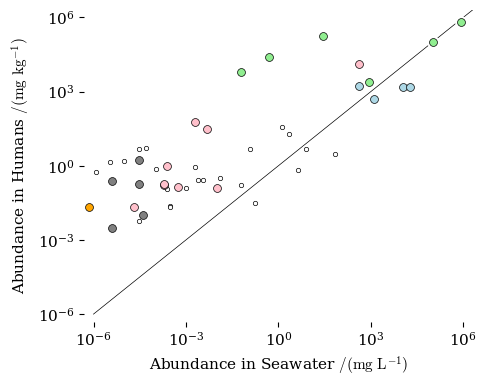

<Figure size 500x400 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

df = df.sort_values("W1") # Sort the DataFrame by the atomic number column in ascending order to ensure that the lines in the plot connect the points in the correct order.
styles_location = "../../../styles/"
plt.rcParamsDefault
plt.style.use(styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

size = 10
color = 'black'
plt.figure(figsize=(5, 4))

# List of elements to plot. excludes noble gases and unstable radioactive elements.
x = df["W1"]
y = df["human"] 
ax.scatter(x, y, 
       marker = "o", s=size, 
       color="white", edgecolor = "black",
       linewidth = 0.5, zorder=3)
ax.scatter(x, y, 
       marker = "o", s=size+20, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.plot([1e-6,2*1e6], [1e-6,2*1e6], color="black", linewidth=0.5, zorder=1) # Add a line y = x to the plot to show where the points would lie if the abundance in the biosphere was equal to the abundance in the crust.

highlightsize = 32
group = [1,6,7,8,15,16] # Create a list of atomic numbers from bounds (inclusive) 
x = df[df["number"].isin(group)]["W1"]
y = df[df["number"].isin(group)]["human"] 
ax.scatter(x, y, 
       marker = "o", s=highlightsize+40, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.scatter(x, y, 
       marker = "o", s=highlightsize, 
       color="lightgreen", edgecolor = "black",
       linewidth = 0.5, zorder=3)

group = [20, 25, 26, 27, 28, 29 ,30, 34, 42, ] # Create a list of atomic numbers from bounds (inclusive) 
x = df[df["number"].isin(group)]["W1"]
y = df[df["number"].isin(group)]["human"] 
ax.scatter(x, y, 
       marker = "o", s=highlightsize+40, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.scatter(x, y, 
       marker = "o", s=highlightsize, 
       color="pink", edgecolor = "black",
       linewidth = 0.5, zorder=3)

group = [11,12,19,17] # Create a list of atomic numbers from bounds (inclusive) 
x = df[df["number"].isin(group)]["W1"]
y = df[df["number"].isin(group)]["human"] 
ax.scatter(x, y, 
       marker = "o", s=highlightsize+40, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.scatter(x, y, 
       marker = "o", s=highlightsize, 
       color="lightblue", edgecolor = "black",
       linewidth = 0.5, zorder=3)

group = [44,45,46,76,78] # Create a list of atomic numbers from bounds (inclusive) 
x = df[df["number"].isin(group)]["W1"]
y = df[df["number"].isin(group)]["human"] 
ax.scatter(x, y, 
       marker = "o", s=highlightsize+40, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.scatter(x, y, 
       marker = "o", s=highlightsize, 
       color="orange", edgecolor = "black",
       linewidth = 0.5, zorder=3)

group = [47,50,79,80,82] # Create a list of atomic numbers from bounds (inclusive) 
x = df[df["number"].isin(group)]["W1"]
y = df[df["number"].isin(group)]["human"] 
ax.scatter(x, y, 
       marker = "o", s=highlightsize+40, 
       color="white", edgecolor = "white",
       linewidth = 0.5, zorder=2)
ax.scatter(x, y, 
       marker = "o", s=highlightsize, 
       color="gray", edgecolor = "black",
       linewidth = 0.5, zorder=3)


ax.set(ylabel=r"Abundance in Humans $\rm /(mg\ kg^{-1})$", 
       xlabel=r"Abundance in Seawater $\rm /(mg\ L^{-1})$",
       yscale="log",
       yticks=[1e-6, 1e-3, 1e0, 1e3, 1e6],
       xscale="log",
       xticks=[1e-6, 1e-3, 1e0,1e3, 1e6],
       xlim=[0.5*1e-6,2*1e6],                  
       ylim=[0.5*1e-6,2*1e6],     
      )
#ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   
ax.minorticks_off()

fig.savefig("plot2.pdf")
plt.show()